In [1]:
import sys

print(sys.executable)

c:\CS(AI) Enginering\TY\DL\.venv\Scripts\python.exe


In [2]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\CS(AI) Enginering\TY\DL\.venv\Scripts\python.exe
PyTorch: 2.14.0+cu130
CUDA: 13.0
CUDA Available: True
GPU: NVIDIA GeForce RTX 2050


# Assignment 9
## Image Classification using Pretrained Vision Transformer and Comparison with CNN

### Objective
Perform image classification using a Convolutional Neural Network (CNN)
and a pretrained Vision Transformer (ViT), and compare their performance
using accuracy, precision, recall, F1-score, training time, and confusion matrices.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import time

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 2050


## Dataset

The CIFAR-10 dataset is used for this experiment. It contains 60,000
32×32 colour images belonging to 10 different classes. The dataset
contains 50,000 training images and 10,000 test images.

In [5]:
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [6]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_cnn
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_cnn
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 50000
Testing samples: 10000


In [7]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Number of classes:", len(classes))
print(classes)

Number of classes: 10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
# Get a small batch of images
visual_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

images, labels = next(iter(visual_loader))

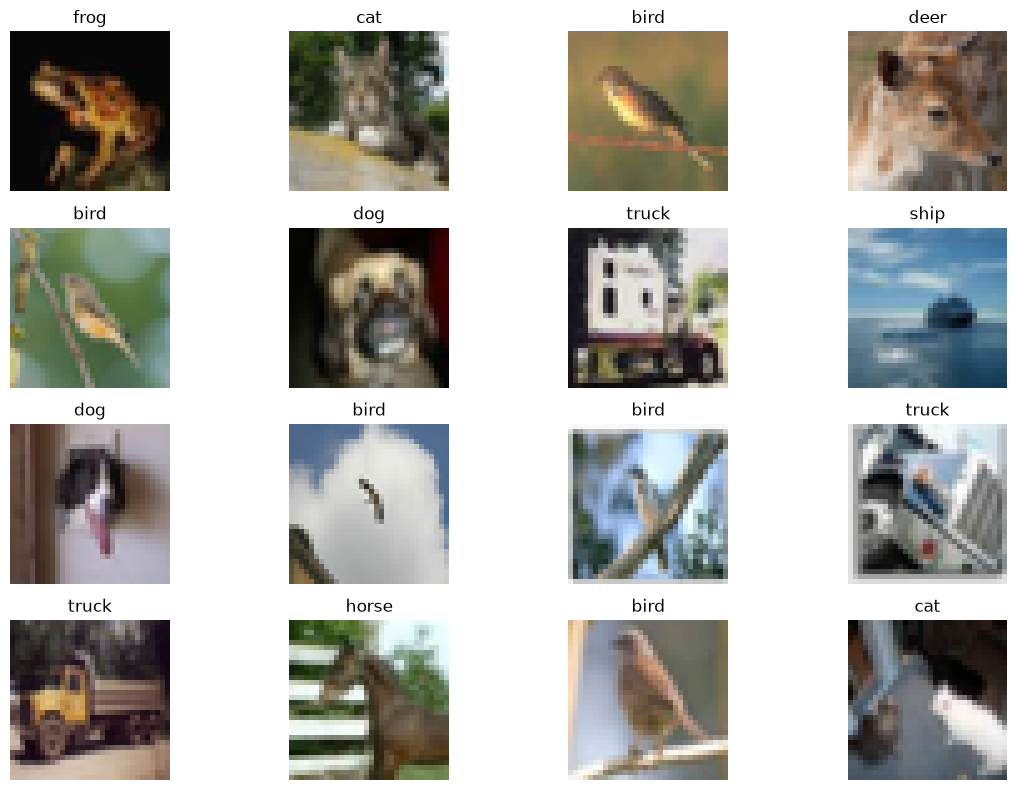

In [9]:
plt.figure(figsize=(12, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    # Convert normalized tensor back to image
    image = images[i].numpy().transpose(1, 2, 0)

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 782
Test batches: 157


## CNN Model

A Convolutional Neural Network is implemented as the baseline model.
The CNN consists of convolutional layers, ReLU activation, max-pooling,
dropout, and fully connected layers.

In [11]:
class CNNModel(nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [12]:
cnn_model = CNNModel().to(device)

print(cnn_model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [13]:
cnn_parameters = sum(
    p.numel()
    for p in cnn_model.parameters()
)

print(
    "CNN Parameters:",
    f"{cnn_parameters:,}"
)

CNN Parameters: 620,362


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

print("CNN optimizer created successfully!")

CNN optimizer created successfully!


In [15]:
cnn_epochs = 10

cnn_train_losses = []
cnn_train_accuracies = []

start_time = time.time()

for epoch in range(cnn_epochs):

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        cnn_optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        cnn_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    cnn_train_losses.append(epoch_loss)
    cnn_train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{cnn_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

cnn_training_time = time.time() - start_time

print(f"\nCNN Training Time: {cnn_training_time:.2f} seconds")

Epoch [1/10] Loss: 1.4696 Accuracy: 46.35%
Epoch [2/10] Loss: 1.0633 Accuracy: 62.44%
Epoch [3/10] Loss: 0.8819 Accuracy: 69.13%
Epoch [4/10] Loss: 0.7759 Accuracy: 72.90%
Epoch [5/10] Loss: 0.6911 Accuracy: 75.93%
Epoch [6/10] Loss: 0.6302 Accuracy: 78.08%
Epoch [7/10] Loss: 0.5698 Accuracy: 80.05%
Epoch [8/10] Loss: 0.5227 Accuracy: 81.72%
Epoch [9/10] Loss: 0.4746 Accuracy: 83.39%
Epoch [10/10] Loss: 0.4330 Accuracy: 84.62%

CNN Training Time: 177.39 seconds


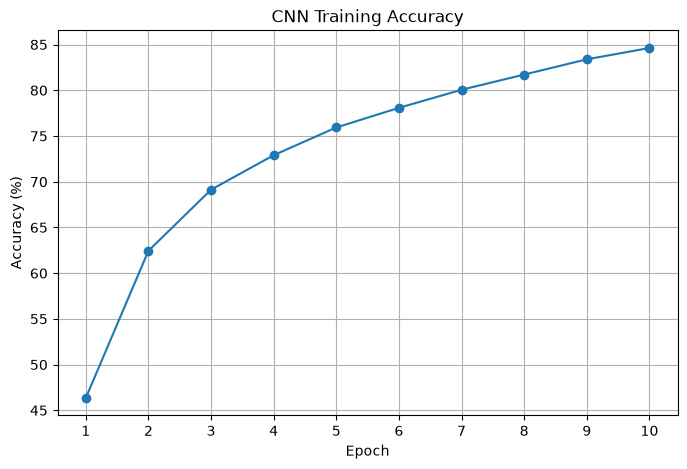

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, cnn_epochs + 1),
    cnn_train_accuracies,
    marker="o"
)

plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, cnn_epochs + 1))
plt.grid()

plt.show()

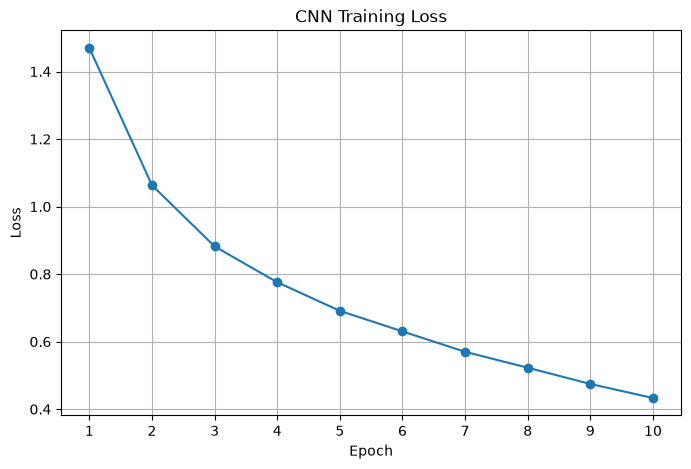

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, cnn_epochs + 1),
    cnn_train_losses,
    marker="o"
)

plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, cnn_epochs + 1))
plt.grid()

plt.show()

In [18]:
cnn_model.eval()

cnn_true = []
cnn_pred = []

start_time = time.time()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = cnn_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        cnn_true.extend(
            labels.numpy()
        )

        cnn_pred.extend(
            predictions.cpu().numpy()
        )

cnn_evaluation_time = time.time() - start_time

cnn_true = np.array(cnn_true)
cnn_pred = np.array(cnn_pred)

print(
    "Evaluation completed in:",
    f"{cnn_evaluation_time:.2f} seconds"
)

Evaluation completed in: 10.11 seconds


In [19]:
cnn_accuracy = accuracy_score(
    cnn_true,
    cnn_pred
)

cnn_precision = precision_score(
    cnn_true,
    cnn_pred,
    average="weighted"
)

cnn_recall = recall_score(
    cnn_true,
    cnn_pred,
    average="weighted"
)

cnn_f1 = f1_score(
    cnn_true,
    cnn_pred,
    average="weighted"
)

print("CNN Performance")
print("------------------------")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1 Score : {cnn_f1:.4f}")

CNN Performance
------------------------
Accuracy : 0.7649
Precision: 0.7664
Recall   : 0.7649
F1 Score : 0.7633


In [20]:
print(
    classification_report(
        cnn_true,
        cnn_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

    airplane       0.73      0.84      0.79      1000
  automobile       0.92      0.81      0.86      1000
        bird       0.72      0.61      0.67      1000
         cat       0.59      0.61      0.60      1000
        deer       0.73      0.73      0.73      1000
         dog       0.72      0.62      0.66      1000
        frog       0.87      0.80      0.83      1000
       horse       0.77      0.83      0.80      1000
        ship       0.80      0.92      0.85      1000
       truck       0.81      0.88      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



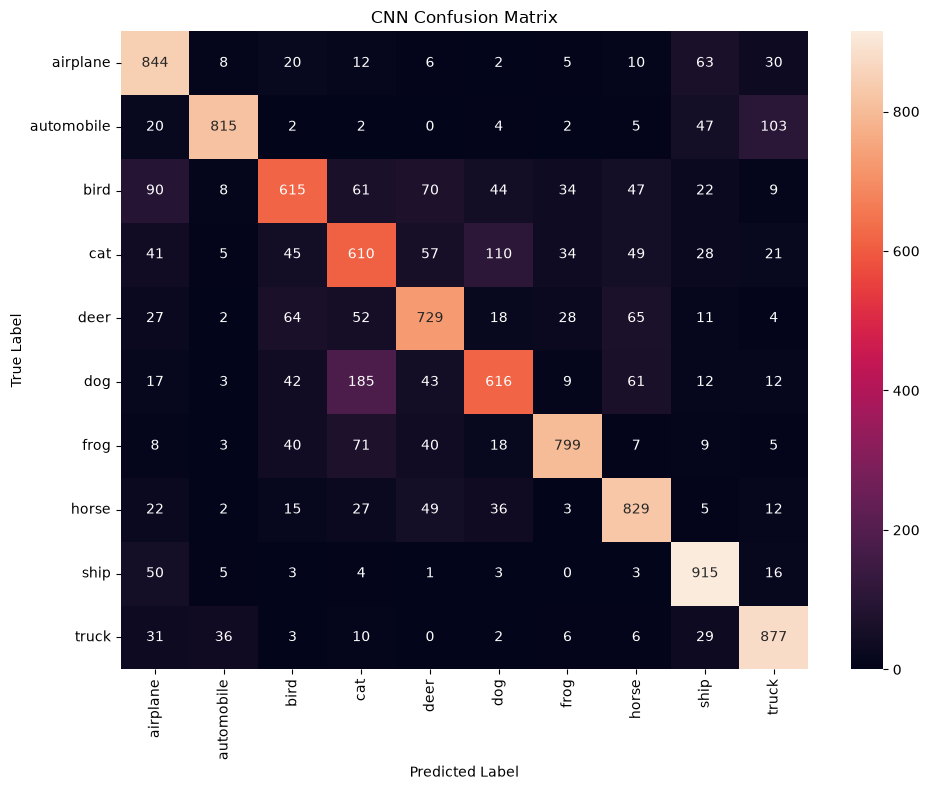

In [21]:
cnn_cm = confusion_matrix(
    cnn_true,
    cnn_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.tight_layout()
plt.show()


## Pretrained Vision Transformer (ViT)

A pretrained Vision Transformer model is used for image classification.
The pretrained model is fine-tuned on the CIFAR-10 dataset.

In [22]:
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [23]:
vit_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=vit_transform
)

vit_test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=vit_transform
)

print("ViT training samples:", len(vit_train_dataset))
print("ViT testing samples:", len(vit_test_dataset))

ViT training samples: 50000
ViT testing samples: 10000


In [24]:
vit_batch_size = 16

vit_train_loader = DataLoader(
    vit_train_dataset,
    batch_size=vit_batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

vit_test_loader = DataLoader(
    vit_test_dataset,
    batch_size=vit_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("ViT train batches:", len(vit_train_loader))
print("ViT test batches:", len(vit_test_loader))

ViT train batches: 3125
ViT test batches: 625


In [25]:
from transformers import ViTForImageClassification

c:\CS(AI) Enginering\TY\DL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=10,
    ignore_mismatched_sizes=True
)

vit_model = vit_model.to(device)

print("Pretrained ViT loaded successfully!")

Could not reach the Hub ([Errno 11001] getaddrinfo failed). Using cached commit hash for 'google/vit-base-patch16-224'.
[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 699.28it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Pretrained ViT loaded successfully!


In [27]:
vit_parameters = sum(
    p.numel()
    for p in vit_model.parameters()
)

print(
    "ViT Parameters:",
    f"{vit_parameters:,}"
)

ViT Parameters: 85,806,346


In [28]:
vit_optimizer = optim.AdamW(
    vit_model.parameters(),
    lr=2e-5
)

vit_criterion = nn.CrossEntropyLoss()

print("ViT optimizer created successfully!")

ViT optimizer created successfully!


In [29]:
images, labels = next(iter(vit_train_loader))

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = vit_model(
        pixel_values=images
    )

print("Output shape:", outputs.logits.shape)

Input shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Output shape: torch.Size([16, 10])


In [30]:
if torch.cuda.is_available():
    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )

    print(
        f"GPU memory reserved: "
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

GPU memory allocated: 0.35 GB
GPU memory reserved: 0.55 GB


In [31]:
vit_epochs = 3

vit_train_losses = []
vit_train_accuracies = []

start_time = time.time()

In [32]:
for epoch in range(vit_epochs):

    vit_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in vit_train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        vit_optimizer.zero_grad()

        # Forward pass
        outputs = vit_model(
            pixel_values=images
        )

        logits = outputs.logits

        # Calculate loss
        loss = vit_criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        vit_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            logits,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(vit_train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    vit_train_losses.append(
        epoch_loss
    )

    vit_train_accuracies.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{vit_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

vit_training_time = time.time() - start_time

print(
    f"\nViT Training Time: "
    f"{vit_training_time:.2f} seconds"
)

Epoch [1/3] Loss: 0.1107 Accuracy: 97.17%
Epoch [2/3] Loss: 0.0217 Accuracy: 99.35%
Epoch [3/3] Loss: 0.0131 Accuracy: 99.61%

ViT Training Time: 8487.36 seconds


In [33]:
# Evaluate Vision Transformer on Test Dataset

vit_model.eval()

vit_true = []
vit_pred = []

start_time = time.time()

with torch.no_grad():
    for images, labels in vit_test_loader:
        images = images.to(device, non_blocking=True)

        outputs = vit_model(pixel_values=images)
        predictions = torch.argmax(outputs.logits, dim=1)

        vit_true.extend(labels.numpy())
        vit_pred.extend(predictions.cpu().numpy())

vit_evaluation_time = time.time() - start_time

vit_true = np.array(vit_true)
vit_pred = np.array(vit_pred)

print(f"ViT Evaluation Time: {vit_evaluation_time:.2f} seconds")

ViT Evaluation Time: 293.64 seconds


In [34]:
vit_accuracy = accuracy_score(vit_true, vit_pred)

vit_precision = precision_score(
    vit_true, vit_pred, average="weighted"
)

vit_recall = recall_score(
    vit_true, vit_pred, average="weighted"
)

vit_f1 = f1_score(
    vit_true, vit_pred, average="weighted"
)

print(f"ViT Accuracy  : {vit_accuracy:.4f}")
print(f"ViT Precision : {vit_precision:.4f}")
print(f"ViT Recall    : {vit_recall:.4f}")
print(f"ViT F1 Score  : {vit_f1:.4f}")

ViT Accuracy  : 0.9822
ViT Precision : 0.9823
ViT Recall    : 0.9822
ViT F1 Score  : 0.9822


In [35]:
# ViT Classification Report

print("Vision Transformer Classification Report:\n")

print(
    classification_report(
        vit_true,
        vit_pred,
        target_names=classes
    )
)

Vision Transformer Classification Report:

              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99      1000
  automobile       0.99      0.98      0.99      1000
        bird       0.98      0.99      0.99      1000
         cat       0.98      0.93      0.95      1000
        deer       0.98      0.99      0.98      1000
         dog       0.95      0.97      0.96      1000
        frog       0.99      0.99      0.99      1000
       horse       0.99      0.99      0.99      1000
        ship       0.99      1.00      1.00      1000
       truck       0.98      0.99      0.99      1000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



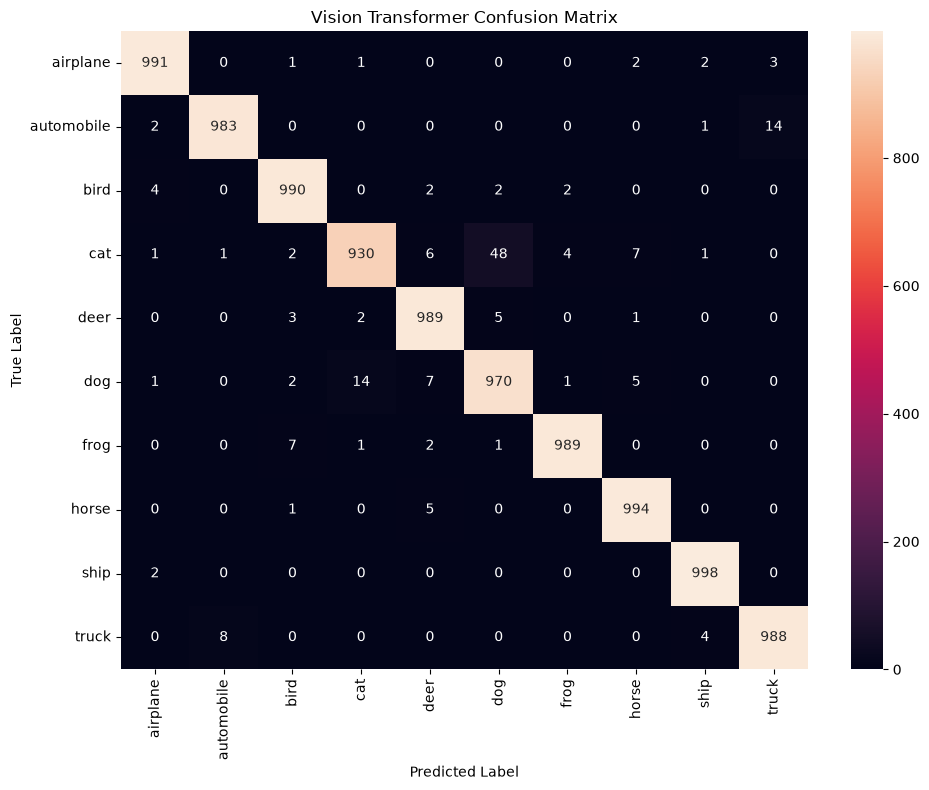

In [36]:
# ViT Confusion Matrix

vit_cm = confusion_matrix(vit_true, vit_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    vit_cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Vision Transformer Confusion Matrix")

plt.tight_layout()
plt.show()

In [37]:
# CNN vs Vision Transformer Comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (seconds)"
    ],
    "CNN": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        cnn_training_time
    ],
    "Pretrained ViT": [
        vit_accuracy,
        vit_precision,
        vit_recall,
        vit_f1,
        vit_training_time
    ]
})

comparison

,Metric,CNN,Pretrained ViT
0,Accuracy,0.764900,0.982200
1,Precision,0.766379,0.982294
2,Recall,0.764900,0.982200
3,F1 Score,0.763266,0.982154
4,Training Time (seconds),177.389951,8487.358924


In [39]:
comparison_display = comparison.copy()

comparison_display.loc[
    comparison_display["Metric"].isin(
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ),
    ["CNN", "Pretrained ViT"]
] *= 100

comparison_display

,Metric,CNN,Pretrained ViT
0,Accuracy,76.490000,98.220000
1,Precision,76.637907,98.229419
2,Recall,76.490000,98.220000
3,F1 Score,76.326622,98.215391
4,Training Time (seconds),177.389951,8487.358924


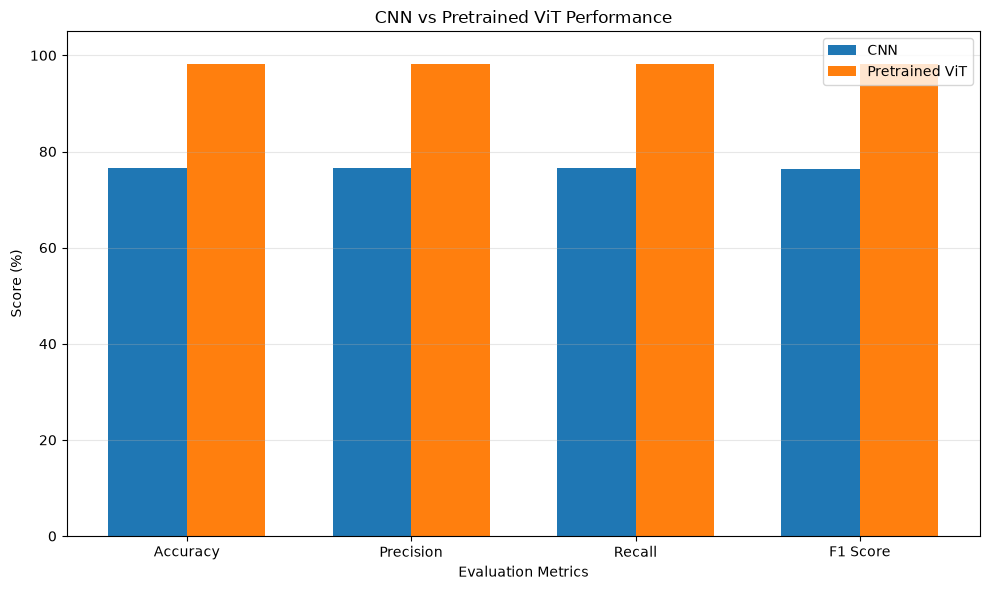

In [40]:
# CNN vs Pretrained ViT Performance Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

cnn_values = [
    cnn_accuracy * 100,
    cnn_precision * 100,
    cnn_recall * 100,
    cnn_f1 * 100
]

vit_values = [
    vit_accuracy * 100,
    vit_precision * 100,
    vit_recall * 100,
    vit_f1 * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, cnn_values, width, label="CNN")
plt.bar(x + width/2, vit_values, width, label="Pretrained ViT")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score (%)")
plt.title("CNN vs Pretrained ViT Performance")
plt.xticks(x, metrics)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

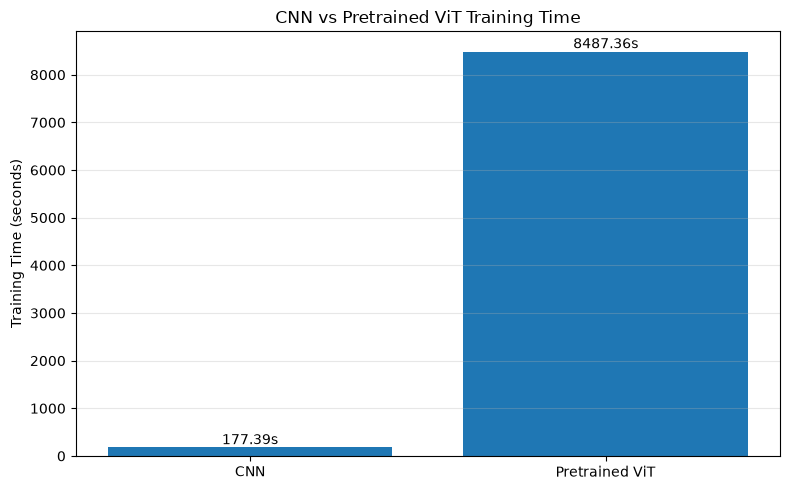

In [41]:
# CNN vs Pretrained ViT Training Time

models = ["CNN", "Pretrained ViT"]
training_times = [cnn_training_time, vit_training_time]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, training_times)

plt.ylabel("Training Time (seconds)")
plt.title("CNN vs Pretrained ViT Training Time")

for bar, time_value in zip(bars, training_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{time_value:.2f}s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The performance of a custom CNN model and a pretrained Vision Transformer (ViT) was compared using the CIFAR-10 dataset.

The CNN achieved an accuracy of 76.49%, while the pretrained ViT achieved a significantly higher accuracy of 98.22%. Similarly, the ViT achieved higher precision (98.23%), recall (98.22%), and F1-score (98.22%) compared to the CNN.

However, the CNN required only 177.39 seconds for training, whereas the ViT required 8487.36 seconds. Therefore, the Vision Transformer provided much better classification performance but required considerably more computational time.

Overall, the pretrained ViT demonstrated superior classification performance on CIFAR-10, while the CNN was much faster to train. This shows the advantage of pretrained transformer-based models when classification accuracy is the priority, whereas CNNs can be preferred when computational resources and training time are limited.